# Task 1: Data Merge — Customer Social Profiles + Transactions

**Goal:** merge `customer_transactions.csv` and `customer_social_profiles.csv` into a single dataset that will later be used to train the **Product Recommendation Model**.

Two problems have to be solved before we can merge:
1. The customer ID format differs between files (`151` vs `A151`).
2. The social profiles file has multiple rows per customer (one per social media platform), so a naive merge would duplicate transactions.

We work through these step by step below.

## 1. Load the raw datasets

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

transactions = pd.read_csv('../data/raw/customer_transactions.csv')
social = pd.read_csv('../data/raw/customer_social_profiles.csv')

print('transactions shape:', transactions.shape)
print('social shape:', social.shape)


transactions shape: (150, 6)
social shape: (155, 5)


In [2]:
transactions.head()

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


In [3]:
social.head()

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


## 2. Inspect data quality

Check data types and missing values in each dataset before doing anything else.

In [4]:
transactions.info()
print()
print('Missing values per column:')
print(transactions.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id_legacy  150 non-null    int64  
 1   transaction_id      150 non-null    int64  
 2   purchase_amount     150 non-null    int64  
 3   purchase_date       150 non-null    str    
 4   product_category    150 non-null    str    
 5   customer_rating     140 non-null    float64
dtypes: float64(1), int64(3), str(2)
memory usage: 7.2 KB

Missing values per column:
customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64


In [5]:
social.info()
print()
print('Missing values per column:')
print(social.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    str    
 1   social_media_platform    155 non-null    str    
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 6.2 KB

Missing values per column:
customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64


**Findings:**
- `transactions` has 150 rows, 75 unique customers. `customer_rating` is missing for 10 rows.
- `social` has 155 rows but only 84 unique customers — some customers show up multiple times (once per platform they use).

## 2b. Exploratory Data Analysis

Before merging, look at the shape of each raw dataset more closely: summary statistics, and the distribution/outliers/category balance that will carry through into the merged dataset and, eventually, the Product Recommendation Model.

In [6]:
print('--- Variable types ---')
print('transactions:')
print(transactions.dtypes)
print()
print('social:')
print(social.dtypes)

print()
print('--- Summary statistics: transactions (numeric columns) ---')
print(transactions.describe())
print()
print('--- Summary statistics: social (numeric columns) ---')
print(social.describe())


--- Variable types ---
transactions:
customer_id_legacy      int64
transaction_id          int64
purchase_amount         int64
purchase_date             str
product_category          str
customer_rating       float64
dtype: object

social:
customer_id_new                str
social_media_platform          str
engagement_score             int64
purchase_interest_score    float64
review_sentiment               str
dtype: object

--- Summary statistics: transactions (numeric columns) ---
       customer_id_legacy  transaction_id  purchase_amount  customer_rating
count          150.000000      150.000000       150.000000        140.00000
mean           148.760000     1075.500000       280.780000          2.98500
std             30.046425       43.445368       121.329595          1.20699
min            100.000000     1001.000000        51.000000          1.00000
25%            121.250000     1038.250000       179.000000          1.95000
50%            150.500000     1075.500000       274.000

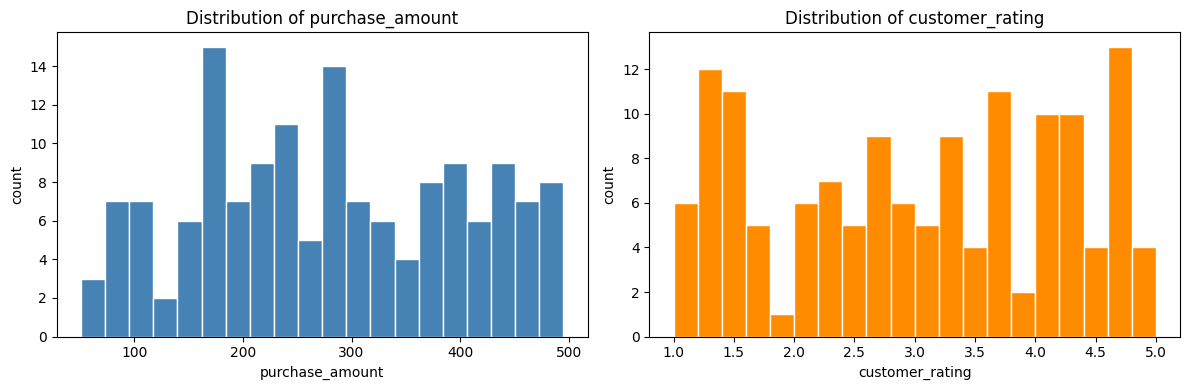

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(transactions['purchase_amount'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of purchase_amount')
axes[0].set_xlabel('purchase_amount')
axes[0].set_ylabel('count')

axes[1].hist(transactions['customer_rating'].dropna(), bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of customer_rating')
axes[1].set_xlabel('customer_rating')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


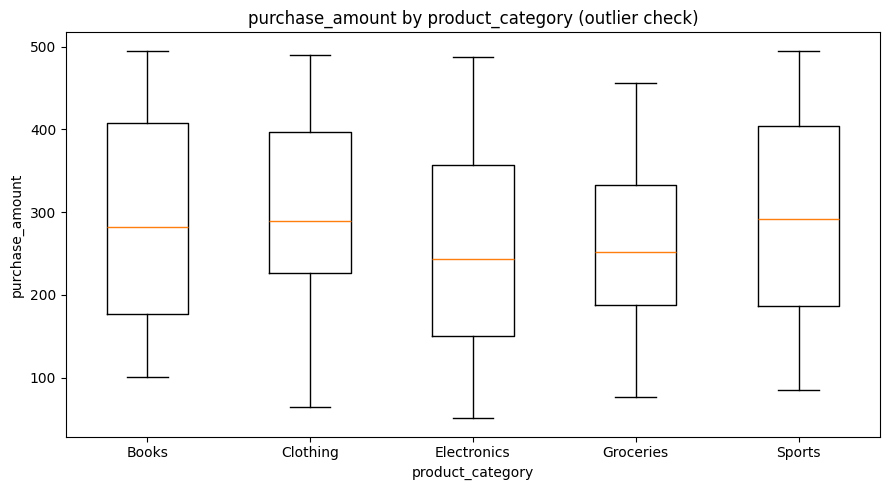

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

categories = sorted(transactions['product_category'].unique())
data_by_cat = [transactions.loc[transactions['product_category'] == c, 'purchase_amount'] for c in categories]

ax.boxplot(data_by_cat, tick_labels=categories)
ax.set_title('purchase_amount by product_category (outlier check)')
ax.set_xlabel('product_category')
ax.set_ylabel('purchase_amount')

plt.tight_layout()
plt.show()


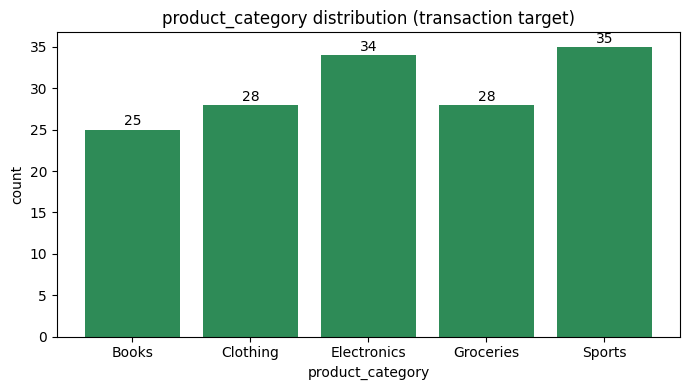

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = transactions['product_category'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='seagreen')
ax.set_title('product_category distribution (transaction target)')
ax.set_xlabel('product_category')
ax.set_ylabel('count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


**EDA insights:**
- `purchase_amount` ranges 51-495 (mean 280.8, std 121.3) with evenly-spaced quartiles (179 / 274 / 388.5) - a roughly uniform spread, not skewed toward either end.
- `customer_rating` covers the full 1-5 scale (mean 2.99, std 1.21) with no unexpected values outside that range.
- The boxplot shows heavily overlapping `purchase_amount` ranges across all 5 categories, with no category visibly shifted higher/lower and no extreme outlier points beyond the whiskers - an early hint that `purchase_amount` alone doesn't separate product categories well, consistent with the weak-signal finding documented later in `04_model_creation.ipynb`.
- `product_category` is reasonably balanced (Books 25, Clothing 28, Electronics 34, Groceries 28, Sports 35) - no class is starved of data, so the Product Recommendation Model's later low accuracy isn't a class-imbalance artifact.

## 3. Align customer IDs

`customer_id_legacy` in transactions is a plain integer (`151`). `customer_id_new` in social profiles is the same number prefixed with `"A"` (`A151`). We strip the prefix and rename both columns to a shared `customer_id` so the two frames can be joined.

In [10]:
transactions = transactions.rename(columns={'customer_id_legacy': 'customer_id'})

social = social.copy()
social['customer_id'] = social['customer_id_new'].str.replace('A', '', regex=False).astype(int)
social = social.drop(columns=['customer_id_new'])

print(transactions['customer_id'].dtype, social['customer_id'].dtype)


int64 int64


## 3b. Remove exact duplicate rows

Before aggregating, check for exact duplicate rows in `social` (same customer, same platform, same scores). If a row is duplicated, it would silently get double weight in the `mean()` aggregation below, slightly skewing that customer's engagement/interest scores.

In [11]:
n_dupes = social.duplicated().sum()
print(f'Exact duplicate rows found: {n_dupes}')
print(social[social.duplicated(keep=False)].sort_values(list(social.columns)))

social = social.drop_duplicates().reset_index(drop=True)
print()
print('social shape after dropping duplicates:', social.shape)


Exact duplicate rows found: 5
    social_media_platform  engagement_score  purchase_interest_score  \
73               LinkedIn                66                      4.7   
150              LinkedIn                66                      4.7   
76                 TikTok                98                      4.8   
154                TikTok                98                      4.8   
118               Twitter                59                      3.8   
152               Twitter                59                      3.8   
78                Twitter                71                      4.8   
153               Twitter                71                      4.8   
18                Twitter                78                      1.1   
151               Twitter                78                      1.1   

    review_sentiment  customer_id  
73          Positive          125  
150         Positive          125  
76          Positive          155  
154         Positive          155

## 4. Collapse social profiles to one row per customer

Since a customer can appear on several platforms, we aggregate to a single profile row per `customer_id`:
- `engagement_score`, `purchase_interest_score` → mean across platforms
- `review_sentiment` → most frequent (mode) sentiment
- `platform_count` → how many distinct platforms the customer uses (new engineered feature)
- `primary_platform` → the platform they show up on most often

This avoids fan-out duplication when we merge with transactions (which already has multiple rows per customer for multiple purchases).

In [12]:
def most_frequent(series):
    return series.mode().iloc[0]

social_agg = social.groupby('customer_id').agg(
    engagement_score=('engagement_score', 'mean'),
    purchase_interest_score=('purchase_interest_score', 'mean'),
    review_sentiment=('review_sentiment', most_frequent),
    primary_platform=('social_media_platform', most_frequent),
    platform_count=('social_media_platform', 'nunique'),
).reset_index()

print('social_agg shape:', social_agg.shape)
social_agg.head()


social_agg shape: (84, 6)


,customer_id,engagement_score,purchase_interest_score,review_sentiment,primary_platform,platform_count
0,100,77.000000,4.400000,Negative,Instagram,2
1,101,68.000000,1.000000,Neutral,Twitter,1
2,102,51.000000,4.800000,Neutral,LinkedIn,1
3,103,64.333333,2.866667,Positive,Instagram,2
4,104,83.000000,2.933333,Negative,Twitter,2


**Caveat on `primary_platform` / `review_sentiment`:** when a customer's platforms (or sentiments) are tied for most-frequent, `.mode().iloc[0]` breaks the tie alphabetically — there's no genuine "primary" platform in that case. This affects **25 of 84 customers (~30%)** for platform and **15 of 84 (~18%)** for sentiment. The tie-break is deterministic (reruns are reproducible) but arbitrary, so treat these two columns as weaker signals for those customers. `platform_count` is unaffected and remains a reliable feature regardless of ties.

## 5. Merge datasets

We use a **left join** on `customer_id`, keeping every transaction row. 14 of the 75 transaction customers have no matching social profile — rather than dropping their transactions (and losing labeled data from an already small dataset), we keep them and impute their social features in the next step.

In [13]:
merged = transactions.merge(social_agg, on='customer_id', how='left')
print('merged shape:', merged.shape)
merged.head()


merged shape: (150, 11)


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,engagement_score,purchase_interest_score,review_sentiment,primary_platform,platform_count
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,2.166667,Neutral,Twitter,2.0
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,4.300000,Positive,Instagram,1.0
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,4.800000,Negative,Facebook,1.0
3,171,1004,256,2024-01-04,Clothing,2.8,NaN,NaN,NaN,NaN,NaN
4,160,1005,64,2024-01-05,Clothing,1.3,72.666667,2.500000,Neutral,Instagram,3.0


## 6. Handle missing values after the merge

Two sources of missing values remain:
- Social features (`engagement_score`, `purchase_interest_score`, `review_sentiment`, `primary_platform`, `platform_count`) are `NaN` for the 14 customers with no social profile.
- `customer_rating` was already missing for 10 transactions before the merge.

We impute numeric fields with the median, categorical fields with an explicit `'Unknown'`/`'No_Platform'` marker (so the model can still learn from "no social profile" as a signal), and `platform_count` with `0`.

Note: we deliberately avoid the literal string `'None'` here — pandas' `read_csv` treats `"None"` as a null marker by default, so it would silently turn back into `NaN` the next time this CSV is loaded.

In [14]:
print('Missing before imputation:')
print(merged.isnull().sum())

merged['engagement_score'] = merged['engagement_score'].fillna(merged['engagement_score'].median())
merged['purchase_interest_score'] = merged['purchase_interest_score'].fillna(merged['purchase_interest_score'].median())
merged['review_sentiment'] = merged['review_sentiment'].fillna('Unknown')
merged['primary_platform'] = merged['primary_platform'].fillna('No_Platform')
merged['platform_count'] = merged['platform_count'].fillna(0).astype(int)
merged['customer_rating'] = merged['customer_rating'].fillna(merged['customer_rating'].median())

print()
print('Missing after imputation:')
print(merged.isnull().sum())


Missing before imputation:
customer_id                 0
transaction_id              0
purchase_amount             0
purchase_date               0
product_category            0
customer_rating            10
engagement_score           33
purchase_interest_score    33
review_sentiment           33
primary_platform           33
platform_count             33
dtype: int64

Missing after imputation:
customer_id                0
transaction_id             0
purchase_amount            0
purchase_date              0
product_category           0
customer_rating            0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
primary_platform           0
platform_count             0
dtype: int64


## 7. Feature engineering

We add a couple of simple derived features from the existing columns:
- `purchase_month` / `purchase_dayofweek` from `purchase_date` (purchase timing can correlate with product category)
- `had_social_profile` flag (1 if the customer had a matching social profile, 0 if imputed)

Categorical encoding (one-hot / label encoding) for modeling is deferred to the model-training notebook, so this merged file stays human-readable and reusable.

In [15]:
merged['purchase_date'] = pd.to_datetime(merged['purchase_date'])
merged['purchase_month'] = merged['purchase_date'].dt.month
merged['purchase_dayofweek'] = merged['purchase_date'].dt.dayofweek
merged['had_social_profile'] = (merged['platform_count'] > 0).astype(int)

merged.head()


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,engagement_score,purchase_interest_score,review_sentiment,primary_platform,platform_count,purchase_month,purchase_dayofweek,had_social_profile
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,2.166667,Neutral,Twitter,2,1,0,1
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,4.300000,Positive,Instagram,1,1,1,1
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,4.800000,Negative,Facebook,1,1,2,1
3,171,1004,256,2024-01-04,Clothing,2.8,77.000000,3.133333,Unknown,No_Platform,0,1,3,0
4,160,1005,64,2024-01-05,Clothing,1.3,72.666667,2.500000,Neutral,Instagram,3,1,4,1


## 7b. Correlation check on the final merged features

Now that all numeric features are assembled, check pairwise correlation - both as a data-quality check (no two engineered features should be accidental near-duplicates) and as an early signal-strength read for the Product Recommendation Model trained in `04_model_creation.ipynb`.

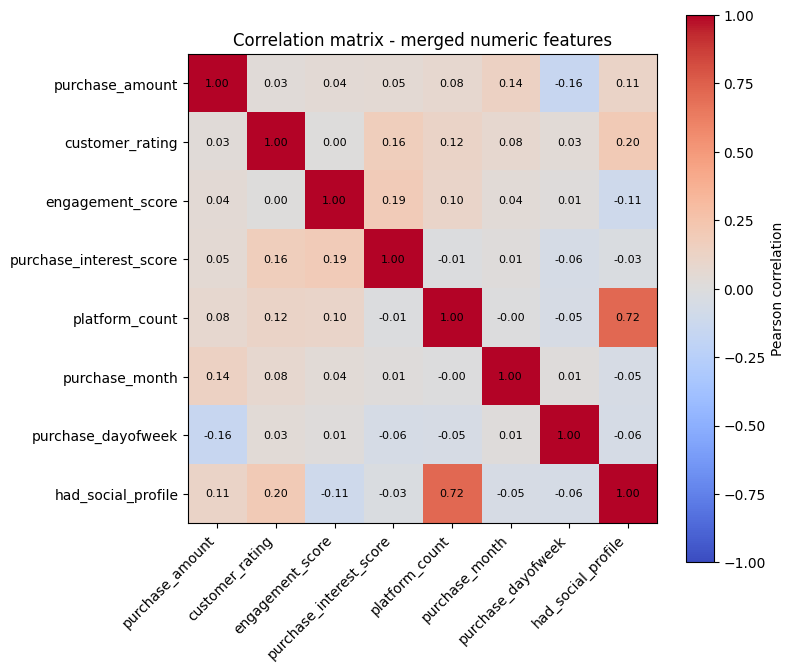

In [16]:
numeric_cols = ['purchase_amount', 'customer_rating', 'engagement_score', 'purchase_interest_score',
                'platform_count', 'purchase_month', 'purchase_dayofweek', 'had_social_profile']
corr = merged[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation matrix - merged numeric features')
fig.colorbar(im, ax=ax, label='Pearson correlation')

plt.tight_layout()
plt.show()


**Correlation insights:**
- The only strong correlation is `platform_count` vs `had_social_profile` (0.72) - expected and not a concern, since `had_social_profile` is defined directly from `platform_count` (`platform_count > 0`); they're mechanically linked, not an accidental leak between independent features.
- Every other pair is weak, all under 0.20 (e.g. `customer_rating` vs `had_social_profile` at 0.20, `engagement_score` vs `purchase_interest_score` at 0.19). Nothing here shows the kind of moderate-to-strong correlation that would let a model reliably predict one column from another.
- Most relevantly, `purchase_amount` (the single strongest numeric predictor found in `04_model_creation.ipynb`) correlates weakly with everything else (all under 0.16), reinforcing the same conclusion reached there: this dataset simply doesn't contain strong linear relationships between the social/behavioral features and purchase outcomes.

## 8. Save the merged dataset

In [17]:
merged.to_csv('../data/processed/merged_customer_data.csv', index=False)
print('Saved data/processed/merged_customer_data.csv with shape', merged.shape)
merged.dtypes


Saved data/processed/merged_customer_data.csv with shape (150, 14)


customer_id                         int64
transaction_id                      int64
purchase_amount                     int64
purchase_date              datetime64[us]
product_category                      str
customer_rating                   float64
engagement_score                  float64
purchase_interest_score           float64
review_sentiment                      str
primary_platform                      str
platform_count                      int64
purchase_month                      int32
purchase_dayofweek                  int32
had_social_profile                  int64
dtype: object